In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"

#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


import jax
jax.config.update("jax_enable_x64", True)

import sys
sys.path.insert(0, "/gpfs/home/jd925/Adding_stellar_masses")

import jaxsp as jsp


import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

import pickle


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/gpfs/home/jd925/miniforge3/envs/keir_env/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 508, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/gpfs/home/jd925/miniforge3/envs/keir_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/gpfs/home/jd925/miniforge3/envs/keir_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


In [2]:

m22 = 10
u = jsp.set_schroedinger_units(m22)
no_radius_bins = 1000
r_min = 20
r_max_enclosing_frac = 0.99

In [3]:
cache_dir = os.path.join("/gpfs/home/jd925/Adding_stellar_masses", "precomputed_wf")
os.makedirs(cache_dir, exist_ok=True)
cache_suffix = f"m22_{float(m22):.6g}_rbins_{int(no_radius_bins)}"
r_j_r_fname = os.path.join(cache_dir, f"precomputed_R_j_r_{cache_suffix}.npz")
pkl_fname   = os.path.join(cache_dir, f"precomputed_objs_{cache_suffix}.pkl")

cache_params = {
    'm22': float(m22),
    'r_min': float(r_min),
    'r_max_enclosing_frac': float(r_max_enclosing_frac),
    'no_radius_bins': int(no_radius_bins),
}

def _cache_valid(data, expected):
    for k, v in expected.items():
        if k not in data.files:
            return False
        cached = data[k].item() if data[k].shape == () else data[k]
        if isinstance(v, float):
            if not np.isclose(cached, v):
                return False
        elif cached != v:
            return False
    return True

R_j_r = None
if os.path.isfile(r_j_r_fname) and os.path.isfile(pkl_fname):
    data = np.load(r_j_r_fname)
    if _cache_valid(data, cache_params):
        print(f"Loading precomputed R_j_r from {r_j_r_fname}...")
        R_j_r = data['R_j_r']
        rmin = data['rmin'].item()
        rmax = data['rmax'].item()
        with open(pkl_fname, 'rb') as f:
            objs = pickle.load(f)
        eigenstate_lib    = objs['eigenstate_lib']
        wavefunction_params = objs['wavefunction_params']
        eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0, None))

    else:
        print(f"Cached {r_j_r_fname} stale (parameter mismatch); recomputing.")

if R_j_r is None:

    cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun,
    25.690207,
    0.407461,
    0.012670 * u.from_Kpc,
    1.857991 * u.from_Kpc,
    3.729259
    ])

    density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

    N = 512
    rmin = .1 * u.from_pc
    rmax = jsp.enclosing_radius(0.999, density_params)
    potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)

    eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

    N = 1024
    a = 1
    b = 10

    rmax = jsp.enclosing_radius(r_max_enclosing_frac, density_params)
    eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)


    rmin = r_min * u.from_pc

    tol = 1e-7
    wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol)


    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), no_radius_bins)
    R_j_r = eval_library(r, eigenstate_lib.radial_eigenmode_params)  # (Nr, Nj)

    np.savez(r_j_r_fname, R_j_r=np.array(R_j_r), rmin=rmin, rmax=rmax, **cache_params)
    with open(pkl_fname, 'wb') as f:
        pickle.dump({'eigenstate_lib': eigenstate_lib, 'wavefunction_params': wavefunction_params}, f)

aj_2 = wavefunction_params.aj_2
aj = np.sqrt(aj_2)

l = eigenstate_lib.radial_eigenmode_params.l
print(max(l))
n = eigenstate_lib.radial_eigenmode_params.n

eigen_energies = eigenstate_lib.radial_eigenmode_params.E

nl_labels = list(zip(l.tolist(), n.tolist()))



Loading precomputed R_j_r from /gpfs/home/jd925/Adding_stellar_masses/precomputed_wf/precomputed_R_j_r_m22_10_rbins_1000.npz...
240


[0.04247516 0.04304858 0.00010557 0.00166667 0.00490672 0.08462902
 0.00128361 0.00064544 0.02651125 0.00042488 0.03203516 0.02970538
 0.02991371 0.06252417 0.00740821 0.04959608 0.04753546 0.00069915
 0.00106605 0.00016703]


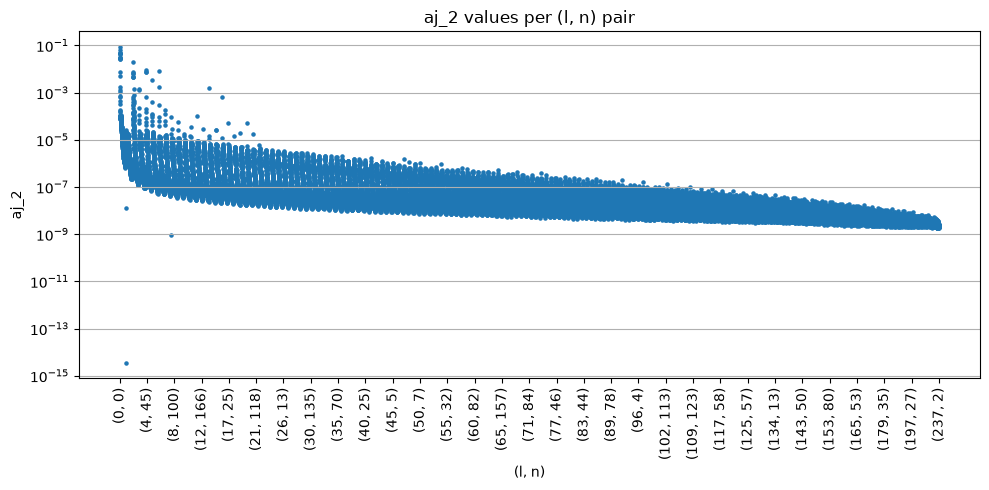

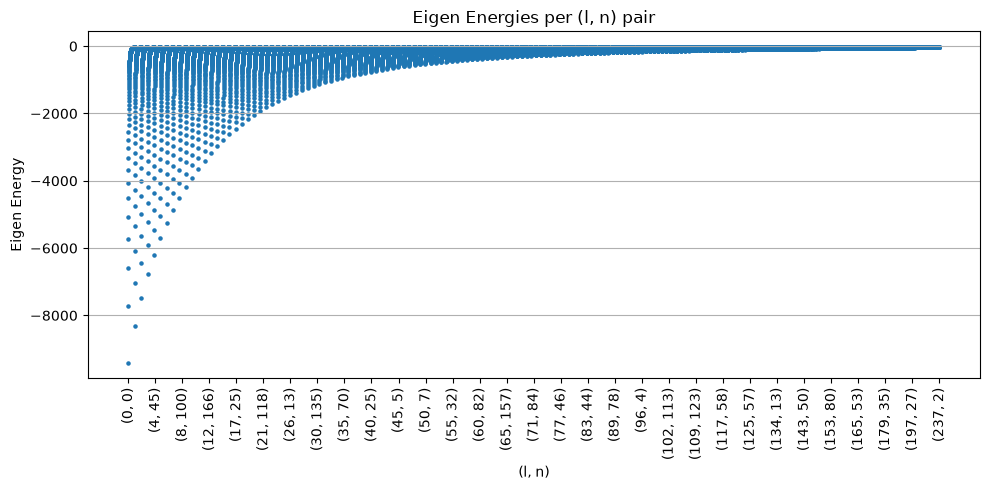

smallest time period [Gyr]: 0.0024506627265470414


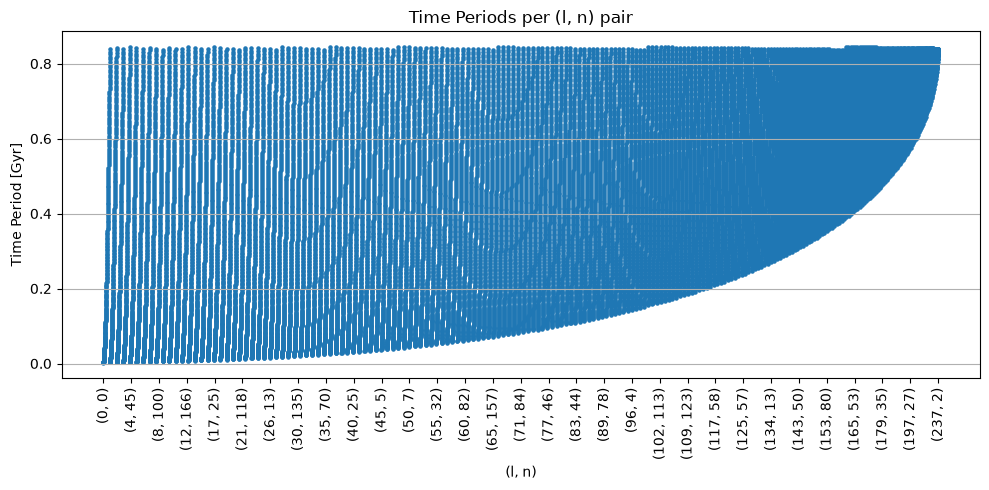

In [6]:


plt.figure(figsize=(10, 5))
plt.scatter(range(len(aj_2)), aj_2, s=5)
print(aj_2[0:20])

step = max(1, len(nl_labels) // 30)  # show ~30 labels
tick_positions = range(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('aj_2')
plt.title('aj_2 values per (l, n) pair')
plt.grid(axis='y')
plt.yscale('log')
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))
plt.scatter(range(len(eigen_energies)), eigen_energies, s = 5)

plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Eigen Energy')
plt.title('Eigen Energies per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

time_periods = -(1 / eigen_energies) * u.to_Gyr

print('smallest time period [Gyr]:', time_periods.min())

plt.figure(figsize=(10, 5))
plt.scatter(range(len(time_periods)), time_periods, s = 5)

plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=10)

plt.xlabel('(l, n)')
plt.ylabel('Time Period [Gyr]')
plt.title('Time Periods per (l, n) pair')
plt.grid(axis='y')
plt.tight_layout()
plt.show()




# Plotting beat frequencies

In [7]:
r_half = 0.19 * u.from_Kpc

sigma_kms  = 5.5
lam_dB_kpc = 19.15 / (m22 * sigma_kms)                    # ℏ/(m σ)
f_c        = (sigma_kms * 1.022) / (2 * np.pi * lam_dB_kpc)  # 1/τ_c   [cycles/Gyr]

f_orb      = 1 / (2 * np.pi * r_half / sigma_kms * u.from_kms) / u.to_Gyr # orbital frequency at r_half [cycles/Gyr]


print('orbital period [cycles Gyr]:', 1/f_orb)

R0 = r_half

R_j_r = eval_library(jnp.array([R0]), eigenstate_lib.radial_eigenmode_params)[0] 

# Per-eigenstate weight at R0, summed over m: (2l+1) |a_j|^2 |R_j(R0)|^2
# (Y_lm averaged over m at fixed l gives (2l+1)/(4π); the constant prefactor
#  doesn't affect the histogram shape, so drop it.)

w_j = np.array(aj_2 * (2*l + 1) * jnp.abs(R_j_r)**2)  # (Nj,)

#beat spectrum
E = np.array(eigen_energies)                               # code units
domega_code = np.abs(E[:, None] - E[None, :])              # (Nj, Nj)


f_beat = domega_code / (2 * np.pi * float(u.to_Gyr))   # (Nj, Nj)
weight = w_j[:, None] * w_j[None, :]                      # (Nj, Nj)

print('smallest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).min())
print('largest beat period [Gyr]:', (1 / f_beat[f_beat > 0]).max())




orbital period [cycles Gyr]: 2.6087096674224823


smallest beat period [Gyr]: 0.015442800951630253
largest beat period [Gyr]: 8975194755.150879


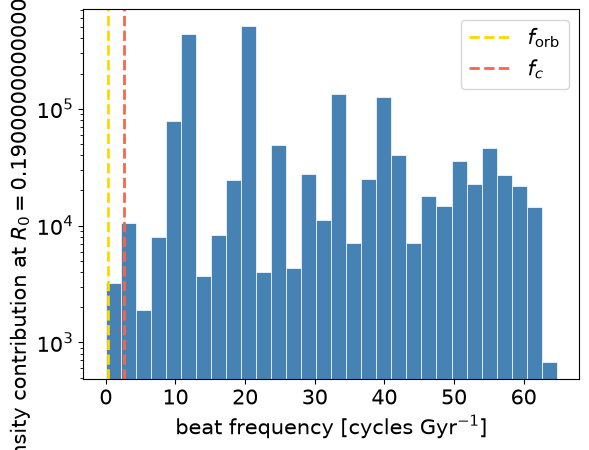

max weight beat period [Gyr]: 0.04870033444838148


In [ ]:
mask = f_beat.ravel() > 0
plt.hist(f_beat.ravel()[mask],
         bins=30, weights=weight.ravel()[mask],
         log=True, alpha = 1, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(f_orb, ls='--', label=r'$f_{\rm orb}$', color='gold', linewidth=2)
plt.axvline(f_c, ls='--', label=r'$f_c$', color='tomato', linewidth=2)
plt.xlabel(r'beat frequency [cycles Gyr$^{-1}$]', fontsize=15)
plt.ylabel(f'Density contribution at $R_0 = {round(R0 * u.to_Kpc, 2)}$ kpc', fontsize=15)
plt.legend(fontsize=15, loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

max_weight_freq = np.where(weight.ravel()[mask] == weight.ravel()[mask].max(), f_beat.ravel()[mask], np.nan)
max_weight_period = 1 / max_weight_freq
print('max weight beat period [Gyr]:', max_weight_period[~np.isnan(max_weight_period)].min())

In [ ]:
order = np.argsort(f_beat.ravel())
f_sorted = f_beat.ravel()[order]
w_sorted = weight.ravel()[order]
mask = f_sorted > 0
cum = np.cumsum(w_sorted[mask])
cum /= cum[-1]                     # fraction of total weight below f

plt.semilogx(f_sorted[mask], cum)
plt.axvline(f_orb, color='g', ls='--', label=r'$f_{\rm orb}$')
plt.axvline(f_c,   color='r', ls='--', label=r'$f_c$')
plt.xlabel(r'$f$ [Gyr$^{-1}$]'); plt.ylabel('cumulative weight fraction')
plt.legend(); plt.show()

# fraction of weight in the "impulsive" band (above a few × f_orb)
above_3forb = (f_sorted > 3*f_orb)
print('weight fraction with f > 3 f_orb:', w_sorted[above_3forb].sum() / w_sorted.sum())


## Heat map for $a_{nl}R_{nl}(r_*)a_{n'l'}R_{n'l'}(r_*)$


(28658,)
(1000, 28658)
(4, 28658)
10857
Plotting heatmap for r_star = 0.50 kpc...


Plotting heatmap for r_star = 1.00 kpc...
Plotting heatmap for r_star = 1.50 kpc...
Plotting heatmap for r_star = 2.00 kpc...


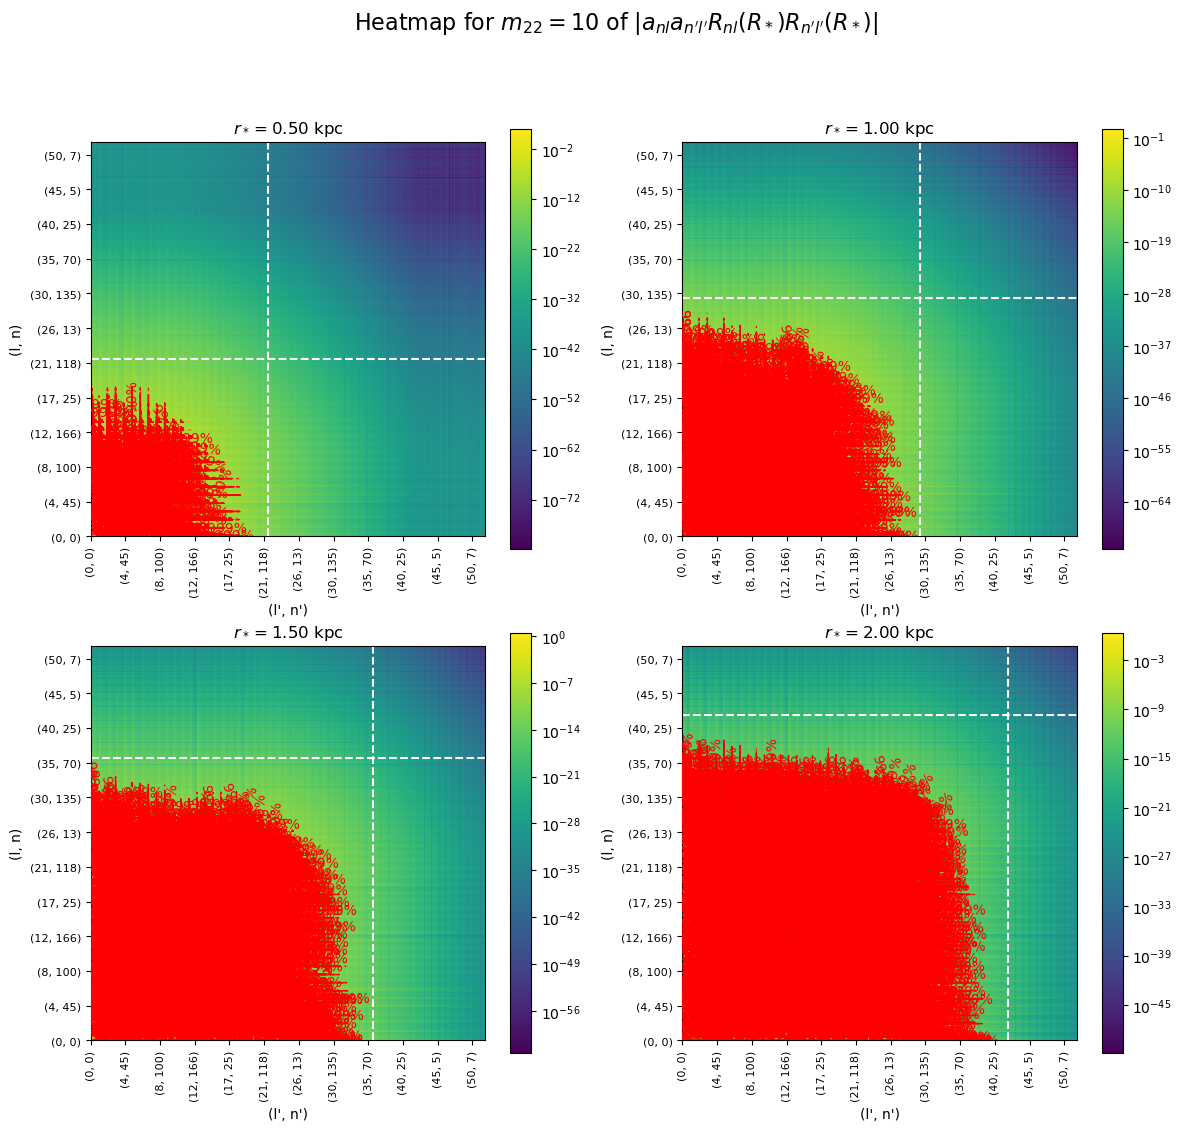

In [ ]:
r_star = np.array([0.5, 1, 1.5, 2]) * u.from_Kpc

print(aj.shape)
print(R_j_r.shape)

#evaluate R at r_*

r = np.logspace(jnp.log10(rmin), jnp.log10(rmax), no_radius_bins)

R_evaled = R_j_r[[np.argmin(np.abs([r - r_star])) for r_star in r_star], :]

print(R_evaled.shape)

# construct matrix for (n,l) and (n',l') pairs

l_arr = np.array(l)



# full sorted weight vector per r_star (length N, cheap)
v_full = np.abs(aj)[None, :] * np.abs(R_evaled)  # (n_rstar, N)
true_total = (v_full.sum(axis=1))**2                                          # (n_rstar,)
   

target = 0.99999
cumv = np.cumsum(v_full, axis=1) / v_full.sum(axis=1, keepdims=True)
K_per = (cumv < np.sqrt(target)).sum(axis=1) + 1   # modes needed per r_star
K = int(K_per.max())
K = int(K * 1.5)         
print(K)                

# Plot heatmap

step = max(1, len(nl_labels) // 30)          # ~30 labels
tick_positions = np.arange(0, len(nl_labels), step)
tick_labels = [nl_labels[i] for i in tick_positions]


from matplotlib.colors import LogNorm, SymLogNorm

fig, ax = plt.subplots(2,2, figsize=(14, 12))

n_rstar = len(r_star)

for i in range(n_rstar):

    print(f"Plotting heatmap for r_star = {r_star[i] * u.to_Kpc:.2f} kpc...")
    v_i = v_full[i, :K]
    A = np.outer(v_i, v_i)         # K×K block, no need for the full N×N matrix at all

    total = true_total[i]           # full-matrix total, NOT A.sum()
    asc = np.sort(A.ravel())
    cum_low = np.cumsum(asc) / total

    def level_drop_fraction(p):
        idx = np.searchsorted(cum_low, p)    # cells below here sum to p·total
        return asc[min(idx, len(asc) - 1)]

    keep = [0.99999, 0.9999, 0.999]             # retained fraction
    levels = [level_drop_fraction(1 - k) for k in keep]   # ascending
    label_of = {lv: k for lv, k in zip(levels, keep)}

    im = ax[i//2, i%2].imshow(A, cmap='viridis', norm=LogNorm(),
                origin='lower', aspect='equal', interpolation='nearest')

    cs = ax[i//2, i%2].contour(A, levels=levels, colors='red', linewidths=1.0)
    ax[i//2, i%2].clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L-v))]*100:.3f}%")

    fig.colorbar(im, ax=ax[i//2, i%2])

    ax[i//2, i%2].set_xticks(tick_positions)
    ax[i//2, i%2].set_yticks(tick_positions)
    ax[i//2, i%2].set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax[i//2, i%2].set_yticklabels(tick_labels, fontsize=8)


    ax[i//2, i%2].set_title(f"$r_* = {r_star[i] * u.to_Kpc:.2f}$ kpc")
    ax[i//2, i%2].set_xlabel("(l', n')")
    ax[i//2, i%2].set_ylabel("(l, n)")

    mask = A >= levels[0]

    rows, cols = np.where(mask)

    l_max = max(l[rows].max(), l[cols].max())
    l_max_plot = l_max + 3

    l_max_plot_idx = np.argwhere(l_arr == l_max_plot)[0][0]

    ax[i//2, i%2].axhline(y=l_max_plot_idx, color='white', ls='--', linewidth=1.5)
    ax[i//2, i%2].axvline(x=l_max_plot_idx, color='white', ls='--', linewidth=1.5)

    ax[i//2, i%2].set_xlim(0, K)
    ax[i//2, i%2].set_ylim(0, K)


#plt.tight_layout()
plt.suptitle(r"Heatmap for $m_{22}$" + f"$ = {m22:.0f}$" + r" of $|a_{nl} a_{n'l'} R_{nl}(R_*) R_{n'l'}(R_*)|$", fontsize=16)
plt.show()

r_* = 0.50 kpc: keeping   4759 / 28658 modes -> 99.99999999% of the matrix
r_* = 1.00 kpc: keeping   6491 / 28658 modes -> 99.99999999% of the matrix
r_* = 1.50 kpc: keeping   7737 / 28658 modes -> 99.99999999% of the matrix
r_* = 2.00 kpc: keeping   8746 / 28658 modes -> 99.99999999% of the matrix
Plotting heatmap for r_star = 0.50 kpc...
Plotting heatmap for r_star = 1.00 kpc...
Plotting heatmap for r_star = 1.50 kpc...
Plotting heatmap for r_star = 2.00 kpc...


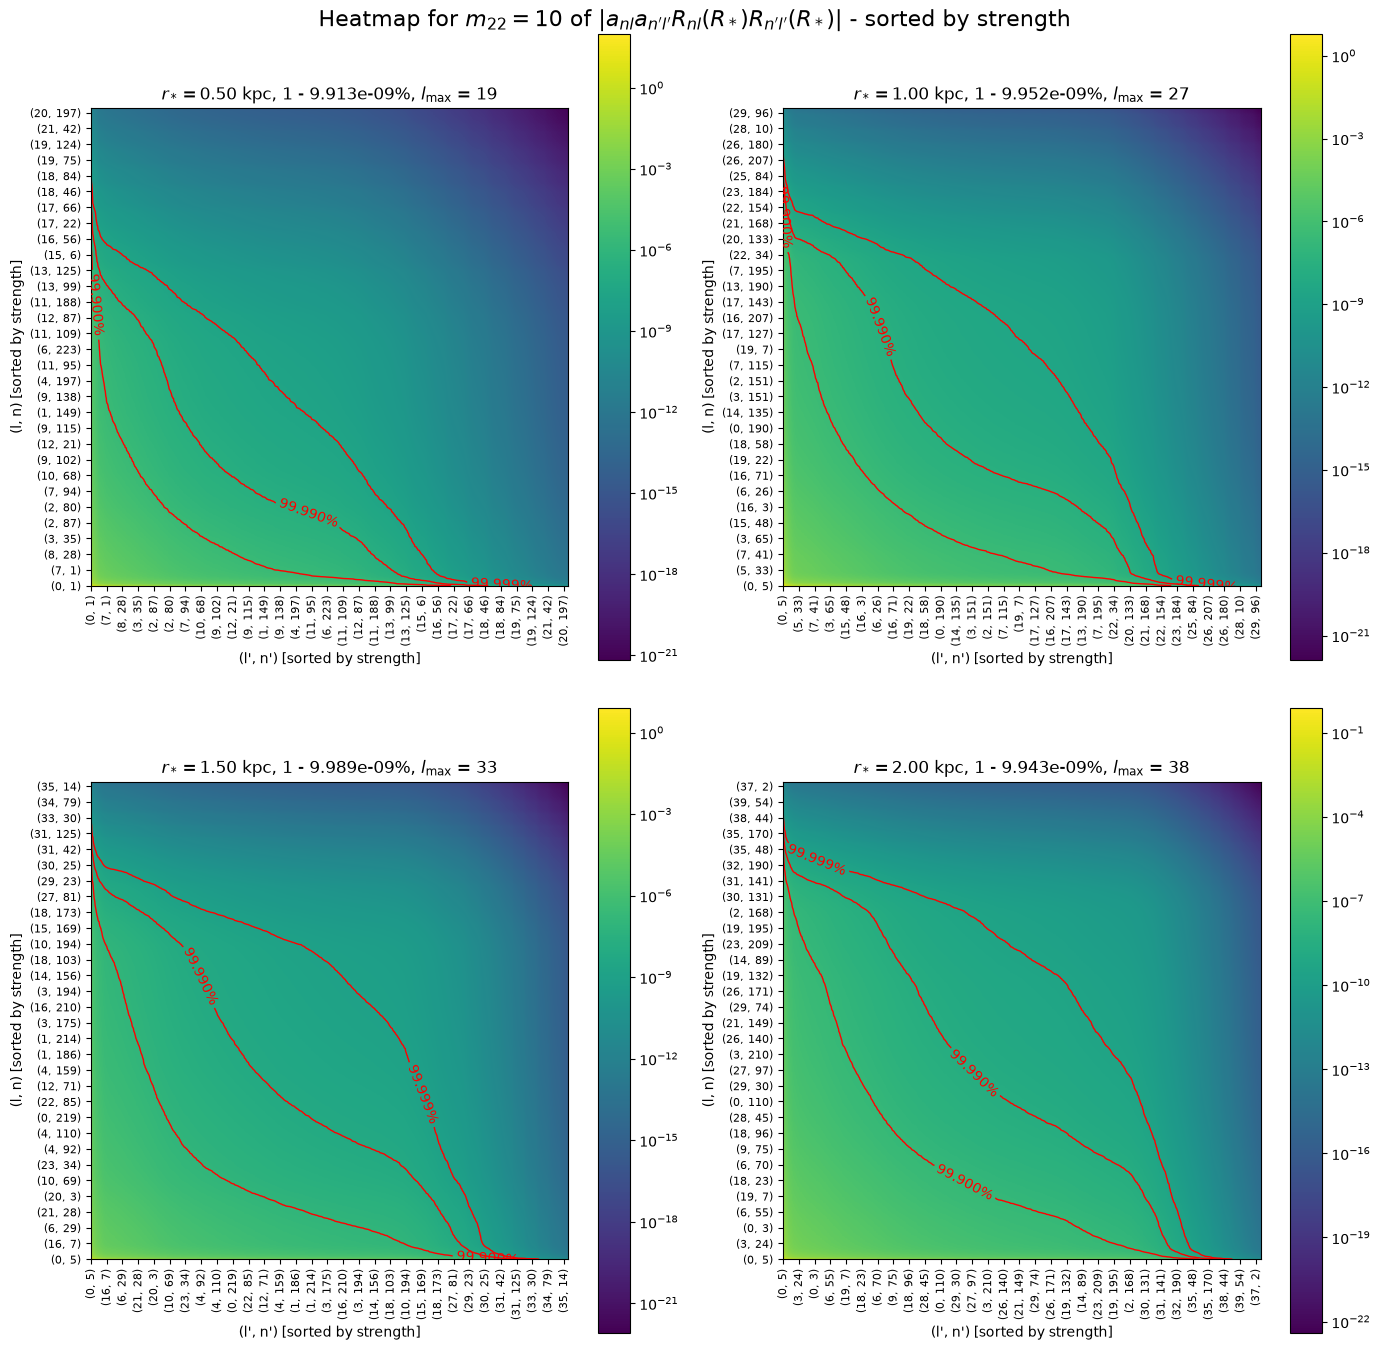

In [5]:
# ---------------------------------------------------------------------------
# Memory-safe rewrite of the heatmap cell above.
#
# Why the cell above OOMs:  A = np.outer(v_i, v_i) is K x K, and K reaches the
# K_max = 100_000 cap  ->  1e10 float64 = 74.5 GiB for ONE panel (and 29.9 GiB
# for the K = 63_380 panel).  matplotlib then copies it again inside LogNorm
# (masked array), again in contour, and again in the Agg resampler, and every
# imshow keeps its array alive in the figure until the figure is closed.
#
# The fix: A is rank-1 (A = v (x) v), and the axes can only ever show ~700 px,
# so downsample v FIRST and build the outer product at display resolution.
# Block-max of a rank-1 matrix == outer(block-max v, block-max v), so the
# picture is exact, not approximated.  Peak memory per panel: ~8 MB.
# ---------------------------------------------------------------------------

import gc
from matplotlib.colors import LogNorm

r_star = np.array([0.5, 1, 1.5, 2]) * u.from_Kpc

target = 1 - 1e-10
K_max  = 800000       # safe to raise now: nothing is ever K^2 in memory
keep   = [0.99999, 0.9999, 0.999]
P_PIX  = 1000         # display cells per axis -> P_PIX^2 * 8 B = 8 MB


def top_modes(v, target=target, K_max=K_max):
    N  = v.size
    Kc = min(K_max, N)
    idx = np.argpartition(v, N - Kc)[N - Kc:]
    idx = idx[np.argsort(v[idx])[::-1]]              # descending
    cum = np.cumsum(v[idx]) / v.sum()
    K   = min(int(np.searchsorted(cum, np.sqrt(target)) + 1), Kc)
    return idx[:K], float(cum[K - 1] ** 2)


def contour_levels(v_kept, total, keep_fracs):
    """Levels L_p of A = outer(v, v) such that the cells below L_p hold a
    fraction (1 - p) of the FULL matrix total.  Bisection on v, never on A."""
    w = np.sort(v_kept[v_kept > 0])
    P = np.concatenate(([0.0], np.cumsum(w)))
    def below(t):
        return float((w * P[np.searchsorted(w, t / w, side='right')]).sum())
    levels = []
    for k in keep_fracs:
        goal   = (1.0 - k) * total
        lo, hi = w[0] ** 2, w[-1] ** 2
        for _ in range(60):
            mid = np.sqrt(lo * hi)
            if below(mid) < goal:
                lo = mid
            else:
                hi = mid
        levels.append(lo)
    return levels


def downsample_desc(v, P=P_PIX):
    """Block-max downsample of a descending v; returns (values, block starts).
    For descending v the block max sits at the block start, so the returned
    positions label the plotted cells exactly."""
    K = v.size
    if K <= P:
        return v, np.arange(K)
    starts = np.linspace(0, K, P + 1)[:-1].astype(int)
    return np.maximum.reduceat(v, starts), starts


l_arr   = np.array(l)
N_modes = l_arr.size

R_evaled_fast   = np.array(eval_library(jnp.asarray(r_star),
                                        eigenstate_lib.radial_eigenmode_params))  # (n_rstar, N)
v_full_fast     = np.abs(aj)[None, :] * np.abs(R_evaled_fast)
true_total_fast = (v_full_fast.sum(axis=1)) ** 2

keep_idx, kept_frac = zip(*[top_modes(v_full_fast[i]) for i in range(len(r_star))])
K_per = np.array([len(k) for k in keep_idx])

for i in range(len(r_star)):
    capped = "  [K_max cap hit - raise K_max for a tighter target]" \
             if K_per[i] == min(K_max, N_modes) < N_modes else ""
    print(f"r_* = {r_star[i] * u.to_Kpc:.2f} kpc: keeping {K_per[i]:6d} / {N_modes} modes "
          f"-> {kept_frac[i] * 100:.8f}% of the matrix{capped}")


fig, ax = plt.subplots(2, 2, figsize=(14, 14))

for i in range(len(r_star)):

    print(f"Plotting heatmap for r_star = {r_star[i] * u.to_Kpc:.2f} kpc...")
    top = keep_idx[i]
    v_i = v_full_fast[i, top]                          # descending, length K_i

    levels   = contour_levels(v_i, true_total_fast[i], keep)
    label_of = {lv: k for lv, k in zip(levels, keep)}

    v_ds, pos = downsample_desc(v_i)                   # <- the whole fix
    A = np.outer(v_ds, v_ds)                           # ~1000 x 1000, 8 MB

    axi = ax[i // 2, i % 2]

    im = axi.imshow(A, cmap='viridis', norm=LogNorm(),
                    origin='lower', aspect='equal', interpolation='nearest')

    cs = axi.contour(A, levels=levels, colors='red', linewidths=1.0)
    axi.clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L - v))] * 100:.3f}%")

    fig.colorbar(im, ax=axi)

    labels_sorted    = [nl_labels[j] for j in top[pos]]
    step_s           = max(1, len(labels_sorted) // 30)
    tick_positions_s = np.arange(0, len(labels_sorted), step_s)
    axi.set_xticks(tick_positions_s)
    axi.set_yticks(tick_positions_s)
    axi.set_xticklabels([labels_sorted[j] for j in tick_positions_s], rotation=90, fontsize=8)
    axi.set_yticklabels([labels_sorted[j] for j in tick_positions_s], fontsize=8)

    axi.set_xlabel("(l', n') [sorted by strength]")
    axi.set_ylabel("(l, n) [sorted by strength]")

    # highest l inside the outermost retained contour, straight from v:
    # A[i,j] >= L  <=>  v_i v_j >= L, and v is descending, so the widest
    # row/col that survives is the last i with v_i * v_0 >= L.
    n_in  = int(np.count_nonzero(v_i * v_i[0] >= levels[0]))
    l_max = int(l_arr[top[:max(n_in, 1)]].max())

    axi.set_title(f"$r_* = {r_star[i] * u.to_Kpc:.2f}$ kpc, 1 - {(1 - kept_frac[i]) * 100:.3e}%, "
                  r"$l_{\rm max}$" + f" = {l_max}")

    del A, v_ds
    gc.collect()

plt.suptitle(r"Heatmap for $m_{22}$" + f"$ = {m22:.0f}$"
             + r" of $|a_{nl} a_{n'l'} R_{nl}(R_*) R_{n'l'}(R_*)|$ - sorted by strength",
             fontsize=16)
plt.tight_layout()
plt.show()


## Heat map for the time scale of oscillations for $dt$ restriction

Plotting beat-timescale heatmap for r_star = 0.50 kpc...


  r_* = 0.50 kpc
    keep 99.999%: fastest retained beat = 0.0002347 Gyr  ->  dt <~ 1.173e-05 Gyr  (= T/20)
    keep 99.990%: fastest retained beat = 0.0002379 Gyr  ->  dt <~ 1.189e-05 Gyr  (= T/20)
    keep 99.900%: fastest retained beat = 0.0002438 Gyr  ->  dt <~ 1.219e-05 Gyr  (= T/20)
Plotting beat-timescale heatmap for r_star = 1.00 kpc...
  r_* = 1.00 kpc
    keep 99.999%: fastest retained beat = 0.000313 Gyr  ->  dt <~ 1.565e-05 Gyr  (= T/20)
    keep 99.990%: fastest retained beat = 0.0003188 Gyr  ->  dt <~ 1.594e-05 Gyr  (= T/20)
    keep 99.900%: fastest retained beat = 0.0003256 Gyr  ->  dt <~ 1.628e-05 Gyr  (= T/20)
Plotting beat-timescale heatmap for r_star = 1.50 kpc...
  r_* = 1.50 kpc
    keep 99.999%: fastest retained beat = 0.0003913 Gyr  ->  dt <~ 1.957e-05 Gyr  (= T/20)
    keep 99.990%: fastest retained beat = 0.0003965 Gyr  ->  dt <~ 1.983e-05 Gyr  (= T/20)
    keep 99.900%: fastest retained beat = 0.0004025 Gyr  ->  dt <~ 2.012e-05 Gyr  (= T/20)
Plotting beat-tim

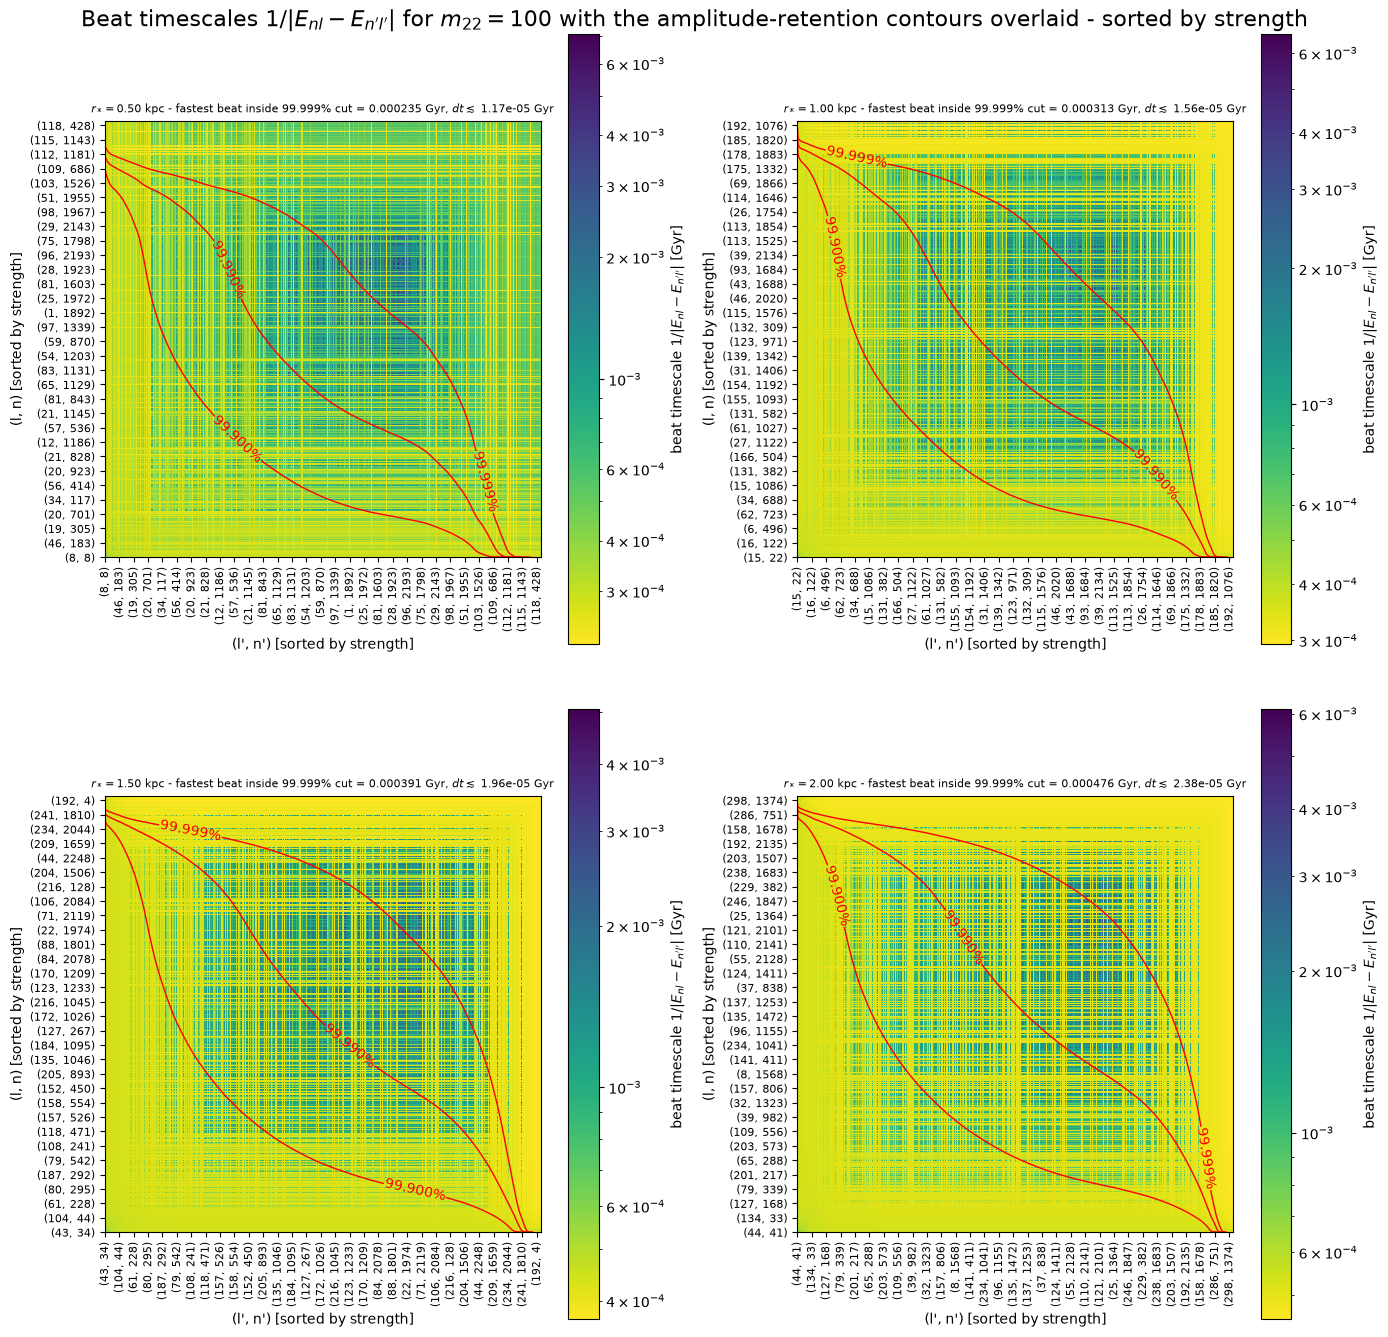


Across all r_*: fastest retained beat at the 99.999% cut = 0.0002347 Gyr  ->  dt <~ 1.173e-05 Gyr


In [5]:
### Beat-timescale heatmap: 1 / |E_nl - E_n'l'|  with the SAME amplitude contours as above
# ---------------------------------------------------------------------------
# Memory-safe rewrite of the cell above.  That one builds THREE K x K arrays per
# panel (A, dE, T_beat) plus the masked copies, i.e. ~3 x 74.5 GiB at K = 100_000.
#
# Two different tricks are needed here, because only one of the two fields is
# rank-1:
#
#   * contour field  A = v (x) v  is rank-1  -> block-max(A) = outer(block-max v)
#     exactly, same as the amplitude cell.
#   * colour field   T = 1/|E_i - E_j|       is NOT rank-1, so it is reduced with
#     a block-MIN (the fast beats are what set dt, and viridis_r draws them
#     bright).  block-min(T) = 1 / block-max(|dE|), and the block max of |dE| is
#     max(Emax_a - Emin_b, Emax_b - Emin_a) from per-block min/max of E - again
#     exact, no K x K array anywhere.
#
#   * the numbers that actually matter - the fastest beat inside each retained
#     contour, which sets dt - are NOT read off the downsampled picture.  They
#     come from `fastest_beat_dE` below, which is exact:
#       min T over {v_i v_j >= L}  ==  1 / max |E_i - E_j| over {v_i v_j >= L},
#     and since v is descending that pair set is a staircase (for each i, all
#     j < J(i)), so prefix max/min of E give the answer in O(K log K).
#
# Peak memory per panel: ~10 MB instead of ~220 GiB.  Verified against the
# brute-force K x K result on random inputs.
# ---------------------------------------------------------------------------

import gc
from matplotlib.colors import LogNorm

E_arr  = np.asarray(eigen_energies)         # code units
safety = 20.0                               # steps per fastest retained beat -> dt suggestion
P_PIX  = 1000                               # display cells per axis (as in the amplitude cell)


def block_starts(K, P=P_PIX):
    """Left edges of P (near-)equal blocks over [0, K)."""
    if K <= P:
        return np.arange(K)
    return np.linspace(0, K, P + 1)[:-1].astype(int)


def fastest_beat_dE(v, E, level):
    """max |E_i - E_j| over the pairs {v_i v_j >= level}, without forming K x K.
    v must be descending and E in the same order.  Returns 0.0 if empty."""
    thr  = level / v
    J    = np.searchsorted(-v, -thr, side='right')      # #{j : v_j >= thr}
    pmax = np.maximum.accumulate(E)
    pmin = np.minimum.accumulate(E)
    ok   = J > 0
    if not ok.any():
        return 0.0
    idx = J[ok] - 1
    return float(np.maximum(pmax[idx] - E[ok], E[ok] - pmin[idx]).max())


fig, ax = plt.subplots(2, 2, figsize=(14, 14))

dt_suggest = {}

for i in range(len(r_star)):

    print(f"Plotting beat-timescale heatmap for r_star = {r_star[i] * u.to_Kpc:.2f} kpc...")

    top   = keep_idx[i]                        # strongest first, already truncated
    v_i   = v_full_fast[i, top]                # descending
    E_top = E_arr[top]                         # same order

    total    = true_total_fast[i]              # full-matrix total
    levels   = contour_levels(v_i, total, keep)   # ascending - identical to the plots above
    label_of = {lv: k for lv, k in zip(levels, keep)}

    # --- display-resolution blocks -----------------------------------------
    starts = block_starts(v_i.size)
    v_ds   = np.maximum.reduceat(v_i,   starts)          # block-max of v
    E_lo   = np.minimum.reduceat(E_top, starts)
    E_hi   = np.maximum.reduceat(E_top, starts)

    A_ds = np.outer(v_ds, v_ds)                          # block-max of A, exact
    dE_ds = np.maximum(E_hi[:, None] - E_lo[None, :],
                       E_hi[None, :] - E_lo[:, None])    # block-max of |dE|, exact
    with np.errstate(divide='ignore', invalid='ignore'):
        T_ds = np.abs(1.0 / dE_ds) * float(u.to_Gyr)     # block-min of T [Gyr]
    T_ds = np.ma.masked_invalid(np.where(dE_ds == 0.0, np.nan, T_ds))

    axi = ax[i // 2, i % 2]

    # viridis_r -> bright = fast beats = the pairs that actually set dt
    im = axi.imshow(T_ds, cmap='viridis_r', norm=LogNorm(),
                    origin='lower', aspect='equal', interpolation='nearest')

    cs = axi.contour(A_ds, levels=levels, colors='red', linewidths=1.0)
    axi.clabel(cs, fmt=lambda v: f"{label_of[min(label_of, key=lambda L: abs(L - v))] * 100:.3f}%")

    fig.colorbar(im, ax=axi, label=r'beat timescale $1/|E_{nl}-E_{n^\prime l^\prime}|$ [Gyr]')

    # ticks in the strength-sorted order (block starts label the plotted cells exactly)
    labels_sorted    = [nl_labels[j] for j in top[starts]]
    step_s           = max(1, len(labels_sorted) // 30)
    tick_positions_s = np.arange(0, len(labels_sorted), step_s)
    axi.set_xticks(tick_positions_s)
    axi.set_yticks(tick_positions_s)
    axi.set_xticklabels([labels_sorted[j] for j in tick_positions_s], rotation=90, fontsize=8)
    axi.set_yticklabels([labels_sorted[j] for j in tick_positions_s], fontsize=8)

    axi.set_xlabel("(l', n') [sorted by strength]")
    axi.set_ylabel("(l, n) [sorted by strength]")

    # fastest beat inside each retained-fraction contour -> the dt each cut demands
    # (exact, from the full K x K pair set - not from the downsampled picture)
    print(f"  r_* = {r_star[i] * u.to_Kpc:.2f} kpc")
    t_min_of_keep = {}
    for lv, k in zip(levels, keep):
        dE_max = fastest_beat_dE(v_i, E_top, lv)
        t_min  = float(np.abs(1.0 / dE_max) * float(u.to_Gyr)) if dE_max > 0 else np.inf
        t_min_of_keep[k] = t_min
        print(f"    keep {k * 100:.3f}%: fastest retained beat = {t_min:.4g} Gyr"
              f"  ->  dt <~ {t_min / safety:.4g} Gyr  (= T/{safety:.0f})")
    dt_suggest[float(r_star[i] * u.to_Kpc)] = t_min_of_keep

    k_tight = max(keep)                        # tightest cut = the one that keeps most modes
    axi.set_title(f"$r_* = {r_star[i] * u.to_Kpc:.2f}$ kpc - "
                  f"fastest beat inside {k_tight * 100:.3f}% cut = {t_min_of_keep[k_tight]:.3g} Gyr, "
                  rf"$dt \lesssim$ {t_min_of_keep[k_tight] / safety:.3g} Gyr", fontsize=8)

    del A_ds, dE_ds, T_ds, v_ds, E_lo, E_hi
    gc.collect()

plt.suptitle(r"Beat timescales $1/|E_{nl}-E_{n^\prime l^\prime}|$ for $m_{22}$" + f"$ = {m22:.0f}$"
             + r" with the amplitude-retention contours overlaid - sorted by strength",
             fontsize=16)

plt.tight_layout()
plt.show()

# global dt from the tightest cut across all r_*
k_tight = max(keep)
t_glob = min(d[k_tight] for d in dt_suggest.values())
print(f"\nAcross all r_*: fastest retained beat at the {k_tight * 100:.3f}% cut = {t_glob:.4g} Gyr"
      f"  ->  dt <~ {t_glob / safety:.4g} Gyr")


In [8]:
desired_l_max = l_max * 1
real_l_max = l_arr.max()

L_out_frac = desired_l_max / real_l_max

print(f"Desired l_max = {desired_l_max:.1f}, real l_max = {real_l_max:.1f}, fraction = {L_out_frac:.3f}")

print(f"Highest included beat frequency: {t_glob:.4g} Gyr")

Desired l_max = 298.0, real l_max = 2413.0, fraction = 0.123
Highest included beat frequency: 0.0002347 Gyr
